###**Preproccessing**

In [16]:
# Core Libraries
import pandas as pd
import numpy as np
import re, html     # Regular expressions & HTML unescaping
import string      # String constants
import seaborn as sb
import matplotlib.pyplot as plt

In [17]:
# Text Normalization & NLP Libraries
import nltk
from nltk.tokenize import word_tokenize, TweetTokenizer     # Text normalization: Tokenization
from nltk import word_tokenize, pos_tag     # Part-of-Speech tagging
from nltk.stem import WordNetLemmatizer     # Text normalization: Lemmatization
from nltk.corpus import wordnet
from nltk.corpus import stopwords     # Remove stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer     # TF-IDF feature extraction

# Download Required NLTK Resources
nltk.download("punkt")     # Tokenizer models
nltk.download("punkt_tab")     # Additional tokenizer tables
nltk.download('stopwords')     # Stopword list
nltk.download('averaged_perceptron_tagger_eng')     # POS tagger
nltk.download('wordnet')     # Lemmatization resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
#Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV     # Splits data into train and test sets
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold

# Evaluation Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [19]:
train_path = "/content/train.csv"
df = pd.read_csv(train_path)   # Load the dataset
df.head()     # observe 5 first rows

,id,tweet,label
0,86426,@USER She should ask a few native Americans wh...,UNT
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN
2,16820,Amazon is investigating Chinese employees who ...,NOT
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT


<Axes: xlabel='label', ylabel='count'>

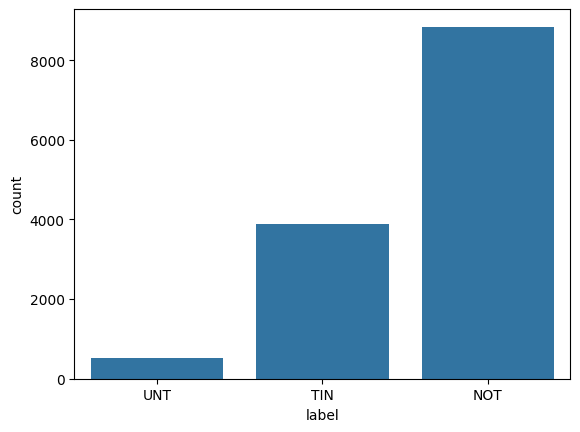

In [20]:
# Summarise class details
sb.countplot(x=df['label'])

In [21]:
print("Shape:", df.shape)
print("\nLabel counts:\n", df["label"].value_counts())

Shape: (13240, 3)

Label counts:
 label
NOT    8840
TIN    3876
UNT     524
Name: count, dtype: int64


In [22]:
df.dropna(inplace=True)
print(f'Number of entries: {len(df)}')

Number of entries: 13240


In [23]:
# Regex normalization
def normalize_profanity(tweet):
    tweet = re.sub(r"\bbull\s*sh\W*t\b", "bullshit", tweet, flags=re.I)
    tweet = re.sub(r"\bsh\W*t\b", "shit", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*ing\b", "fucking", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*s\b", "fucks", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\b", "fuck", tweet, flags=re.I)
    tweet = re.sub(r"\bd\W*mbasses\b", "dumbasses", tweet, flags=re.I)
    tweet = re.sub(r"\bc\W*ck\b", "cock", tweet, flags=re.I)
    return tweet

In [24]:
# convert text to tokens
tokenizer = TweetTokenizer(preserve_case=False,
                    strip_handles=True,
                    reduce_len=True
)
for i in range(5):
    tweet = df["tweet"].iloc[i]
    tokens = tokenizer.tokenize(tweet)
    print("Original:", tweet)
    print("Tokens:", tokens)
    print("-" * 50)

Original: @USER She should ask a few native Americans what their take on this is.
Tokens: ['she', 'should', 'ask', 'a', 'few', 'native', 'americans', 'what', 'their', 'take', 'on', 'this', 'is', '.']
--------------------------------------------------
Original: @USER @USER Go home you’re drunk!!! @USER #MAGA #Trump2020 👊🇺🇸👊 URL
Tokens: ['go', 'home', 'you', '’', 're', 'drunk', '!', '!', '!', '#maga', '#trump2020', '👊', '🇺🇸', '👊', 'url']
--------------------------------------------------
Original: Amazon is investigating Chinese employees who are selling internal data to third-party sellers looking for an edge in the competitive marketplace. URL #Amazon #MAGA #KAG #CHINA #TCOT
Tokens: ['amazon', 'is', 'investigating', 'chinese', 'employees', 'who', 'are', 'selling', 'internal', 'data', 'to', 'third-party', 'sellers', 'looking', 'for', 'an', 'edge', 'in', 'the', 'competitive', 'marketplace', '.', 'url', '#amazon', '#maga', '#kag', '#china', '#tcot']
---------------------------------------

In [25]:
# Merge to tokens back into sentences by adding a space between two tokens.
joined_tokens_list = []
for tweet in df["tweet"]:
    tokens = tokenizer.tokenize(tweet)
    joined_tokens = " ".join(tokens)
    joined_tokens_list.append(joined_tokens)

# add new column to data frame
df["tokenized_tweet"] = joined_tokens_list
df.head()

,id,tweet,label,tokenized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to..."
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...


In [26]:
# Apply POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [27]:
# Lemmatized with WordNet to reduce inflected forms to their base form,
wnl = WordNetLemmatizer()
df["lemmatized_tweet"] = df["tokenized_tweet"].apply(
    lambda tweet_string: " ".join(
        wnl.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in nltk.pos_tag(nltk.word_tokenize(tweet_string))
    )
)
df.head()

,id,tweet,label,tokenized_tweet,lemmatized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...,she should ask a few native american what thei...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...,go home you ’ re drunk ! ! ! # maga # trump202...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...,amazon be investigate chinese employee who be ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to...",someone should'vetaken `` this piece of shit t...
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...,obama want liberal & illegals to move into red...


In [28]:
# get English stopwords
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [29]:
# Define features and labels
X_tweet = df['tweet']
X_tokenized = df['tokenized_tweet']
X_lemmatized = df['lemmatized_tweet']
y = df['label']

In [30]:
# Train / test split
(X_tweet_train, X_tweet_val,
 X_tokenized_train, X_tokenized_val,
 X_lemmatized_train, X_lemmatized_val,
 y_train, y_val) = train_test_split(X_tweet, X_tokenized, X_lemmatized, y, test_size=0.3, random_state=42, stratify=y)

In [31]:
# Sanity check
print("Tweet:", len(X_tweet_train),",", len(X_tweet_val))
print("Tokenized:", len(X_tokenized_train),",", len(X_tokenized_val))
print("Lemmatized:", len(X_lemmatized_train),",", len(X_lemmatized_val))
print("Labels:", len(y_train),",", len(y_val))

Tweet: 9268 , 3972
Tokenized: 9268 , 3972
Lemmatized: 9268 , 3972
Labels: 9268 , 3972


In [32]:
# Evaluation function
def evaluate(actuals, predictions, labels):

    # 1) Accuracy
    accuracy = metrics.accuracy_score(actuals, predictions)
    print(f"Accuracy: {accuracy:.4f}")

    # 2) Precision, Recall, F1 (macro)
    precision = metrics.precision_score(actuals, predictions, average="macro", zero_division=0)
    recall = metrics.recall_score(actuals, predictions, average="macro", zero_division=0)
    f1 = metrics.f1_score(actuals, predictions, average="macro", zero_division=0)

    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")

    # 3) Confusion Matrix
    cm = metrics.confusion_matrix(actuals, predictions, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    # return values
    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm
    }

###**SGDClassifier**

In [33]:
# Train an SGDClassifier classifier and predict on validation data.
def get_SGDClassifier_predictions(X_train, X_val, y_train, y_val):

    # build model
    classifier = SGDClassifier(random_state=42, class_weight="balanced", tol=1e-3, max_iter=2000)
    classifier.fit(X_train, y_train)

    # make predictions on validation data
    y_pred = classifier.predict(X_val)

    # evaluation
    evaluate(y_val, y_pred, labels=["NOT", "TIN", "UNT"])

    return classifier

###**Models**

Accuracy: 0.6979
Precision (macro): 0.5014
Recall (macro):    0.5062
F1-score (macro):  0.5031


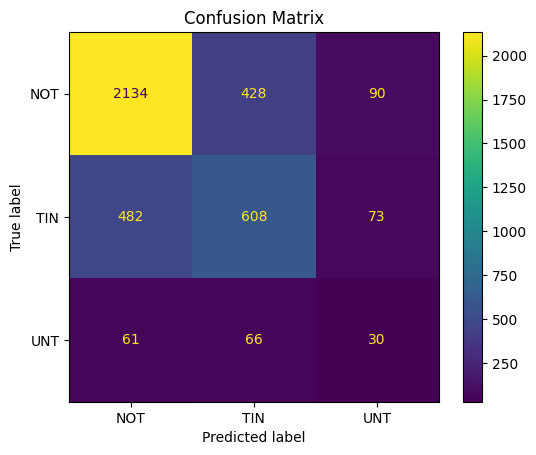

In [34]:
# Model 1 - ngram_range=(1,1)
vectorizer = CountVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m1 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7080
Precision (macro): 0.5225
Recall (macro):    0.4902
F1-score (macro):  0.5016


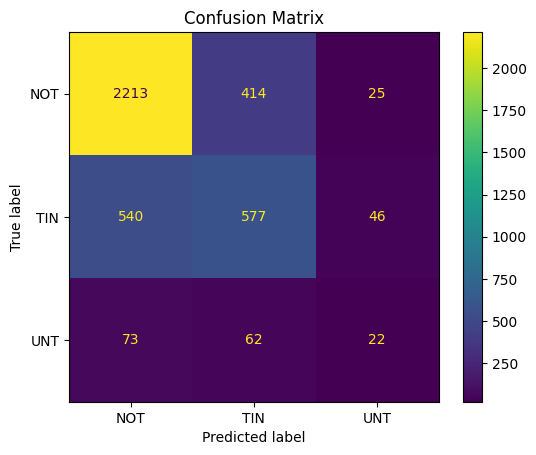

In [35]:
# Model 1 - ngram_range=(1,2)
vectorizer = CountVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m11 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6616
Precision (macro): 0.4633
Recall (macro):    0.3994
F1-score (macro):  0.4047


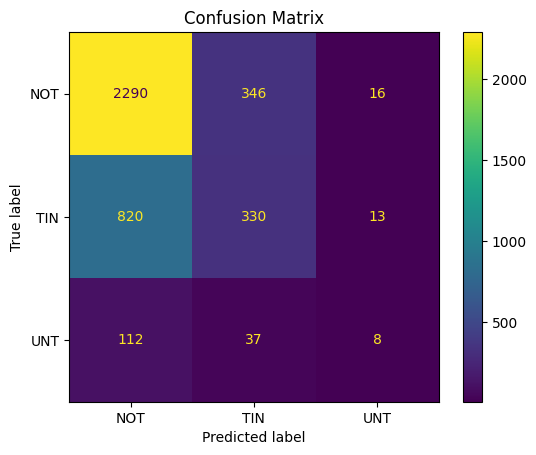

In [36]:
# Model 1 - ngram_range=(2,2)
vectorizer = CountVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m12 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7135
Precision (macro): 0.5299
Recall (macro):    0.4464
F1-score (macro):  0.4599


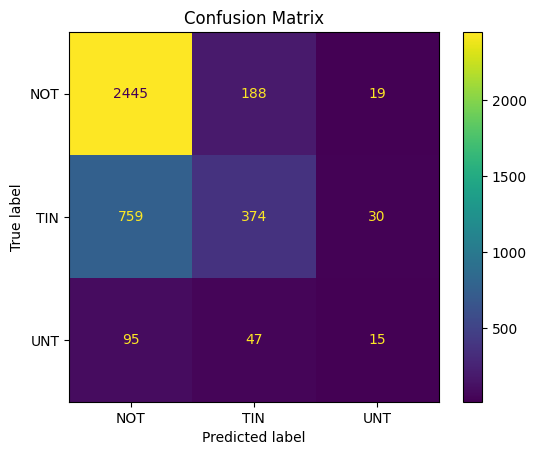

In [37]:
# Model 1 - ngram_range=(1,3)
vectorizer = CountVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m13 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.5539
Precision (macro): 0.3983
Recall (macro):    0.3232
F1-score (macro):  0.3044


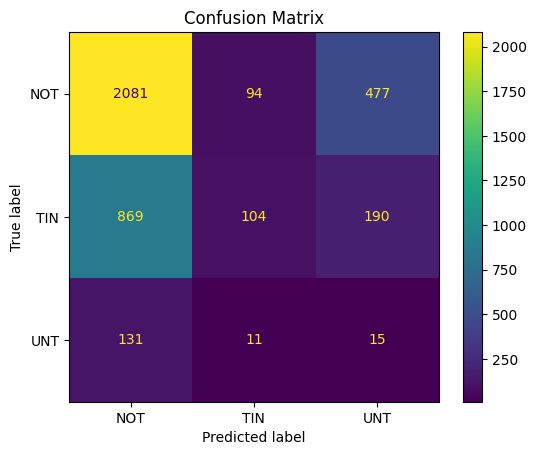

In [38]:
# Model 1 - ngram_range=(3,3)
vectorizer = CountVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m14 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7203
Precision (macro): 0.5027
Recall (macro):    0.4859
F1-score (macro):  0.4924


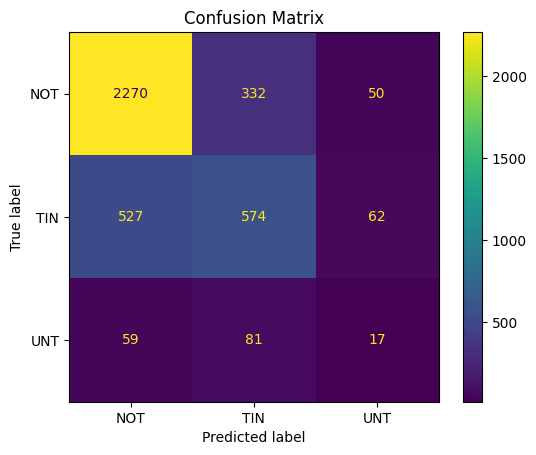

In [39]:
# Model 2 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m2 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7281
Precision (macro): 0.5658
Recall (macro):    0.4843
F1-score (macro):  0.4985


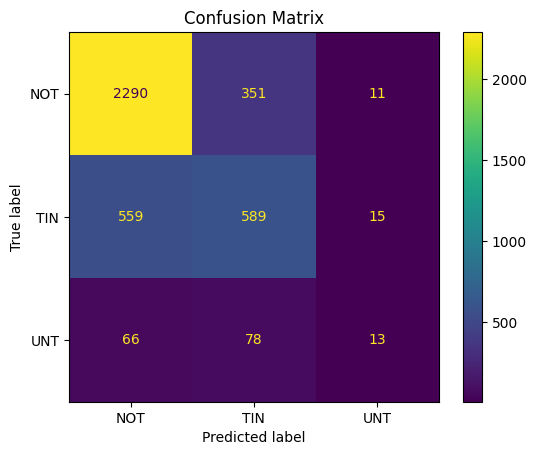

In [40]:
# Model 2 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m21 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6579
Precision (macro): 0.4888
Recall (macro):    0.4105
F1-score (macro):  0.4214


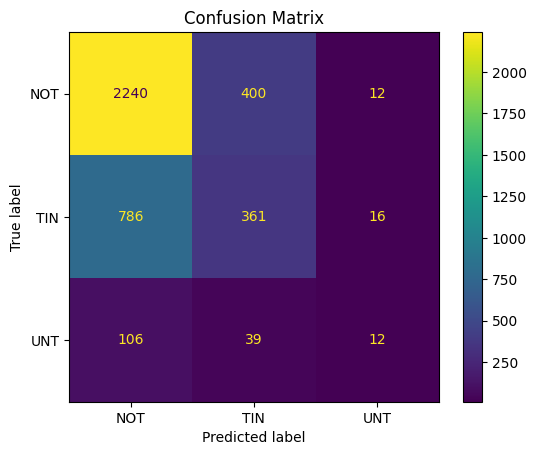

In [41]:
# Model 2 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m22 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7246
Precision (macro): 0.5764
Recall (macro):    0.4803
F1-score (macro):  0.4942


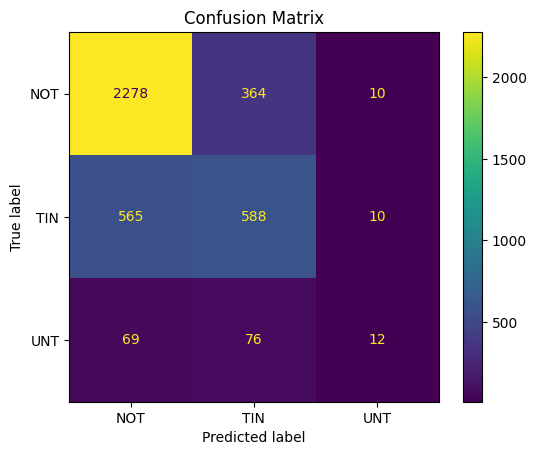

In [42]:
# Model 2 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m23 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6513
Precision (macro): 0.4288
Recall (macro):    0.3703
F1-score (macro):  0.3636


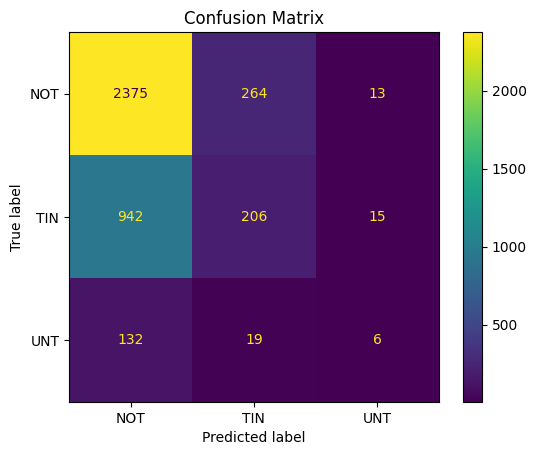

In [43]:
# Model 2 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m24 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7183
Precision (macro): 0.5041
Recall (macro):    0.4889
F1-score (macro):  0.4949


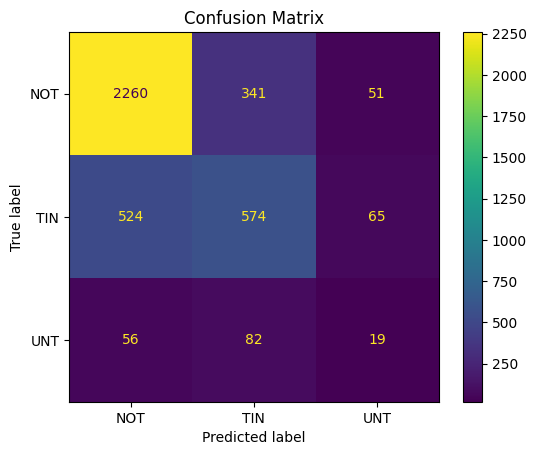

In [44]:
# Model 3 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m3 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7248
Precision (macro): 0.5350
Recall (macro):    0.4855
F1-score (macro):  0.4939


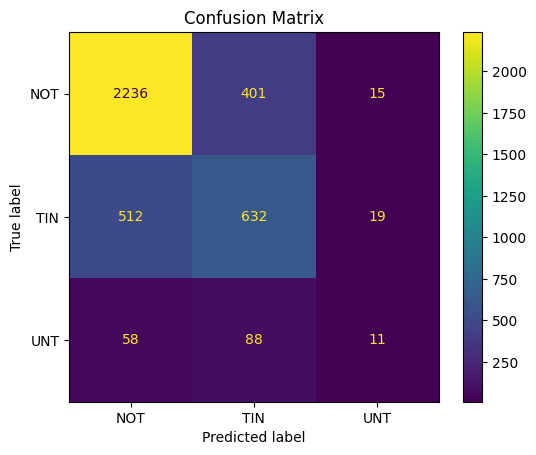

In [45]:
# Model 3 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m31 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6647
Precision (macro): 0.4851
Recall (macro):    0.4077
F1-score (macro):  0.4158


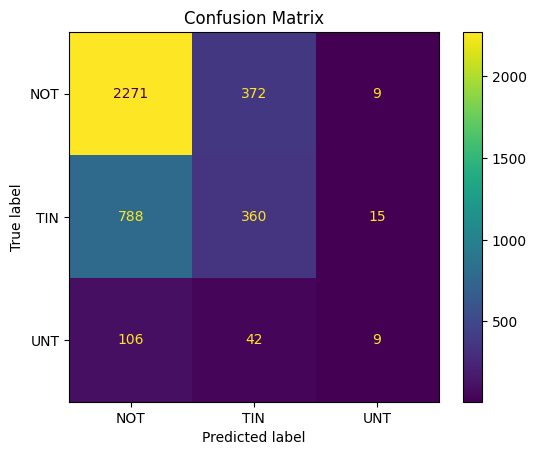

In [46]:
# Model 3 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m32 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7140
Precision (macro): 0.5350
Recall (macro):    0.4793
F1-score (macro):  0.4858


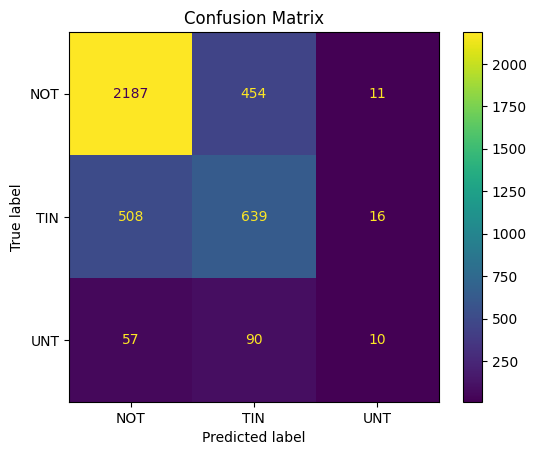

In [47]:
# Model 3 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m33 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6523
Precision (macro): 0.4171
Recall (macro):    0.3587
F1-score (macro):  0.3430


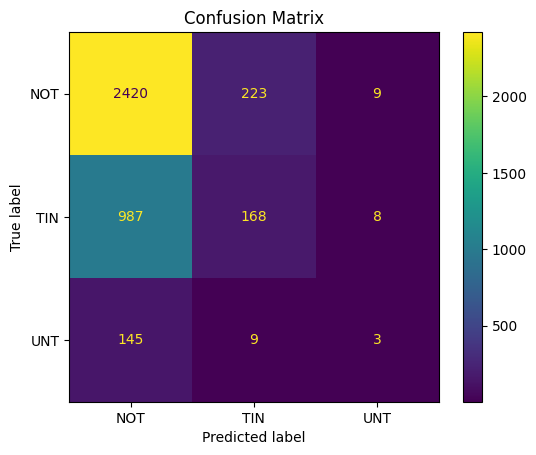

In [48]:
# Model 3 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m34 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7200
Precision (macro): 0.5106
Recall (macro):    0.4999
F1-score (macro):  0.5040


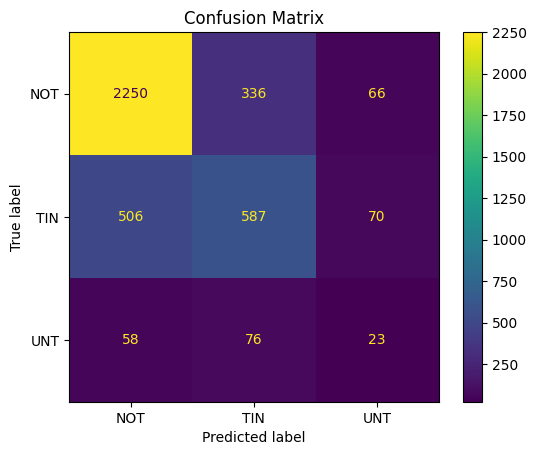

In [49]:
# Model 4 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(ngram_range=(1,1), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m4 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7266
Precision (macro): 0.5220
Recall (macro):    0.4821
F1-score (macro):  0.4885


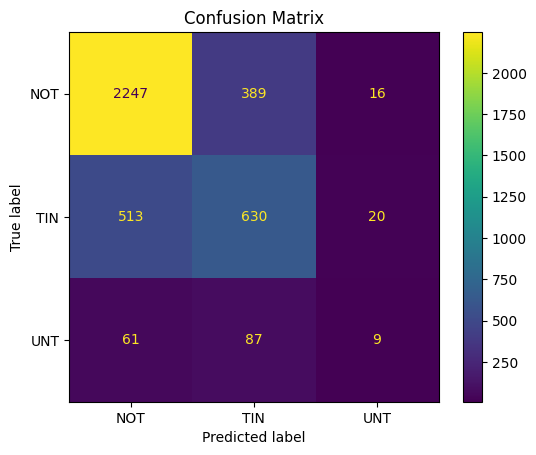

In [50]:
# Model 4 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m41 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6667
Precision (macro): 0.4592
Recall (macro):    0.4094
F1-score (macro):  0.4150


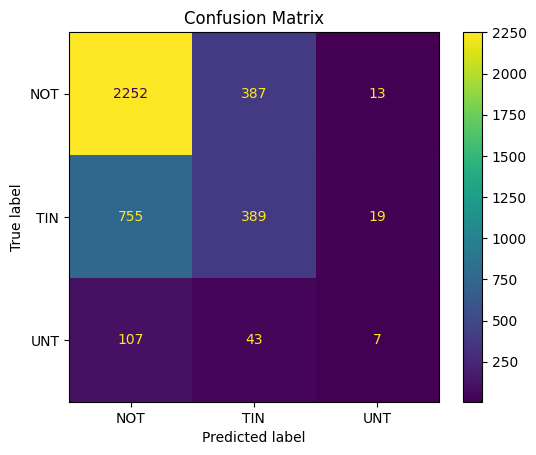

In [51]:
# Model 4 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m42 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7163
Precision (macro): 0.5164
Recall (macro):    0.4808
F1-score (macro):  0.4847


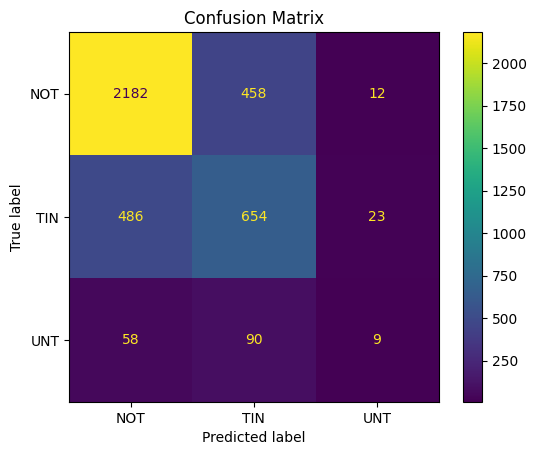

In [52]:
# Model 4 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m43 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6579
Precision (macro): 0.4228
Recall (macro):    0.3621
F1-score (macro):  0.3467


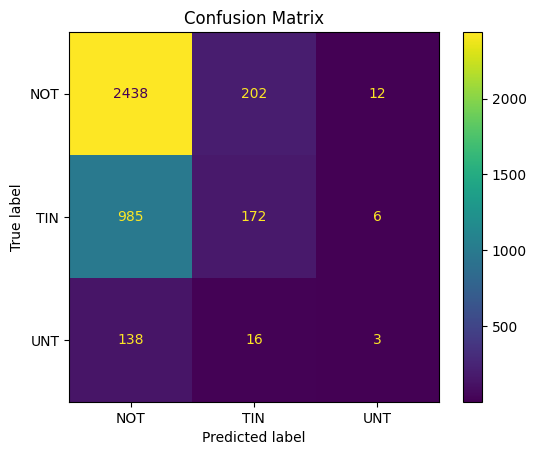

In [53]:
# Model 4 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m44 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7165
Precision (macro): 0.4961
Recall (macro):    0.4825
F1-score (macro):  0.4878


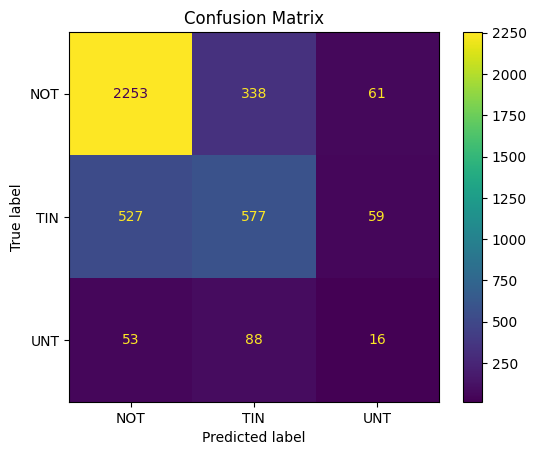

In [54]:
# Model 5 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m5 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7243
Precision (macro): 0.5146
Recall (macro):    0.4830
F1-score (macro):  0.4890


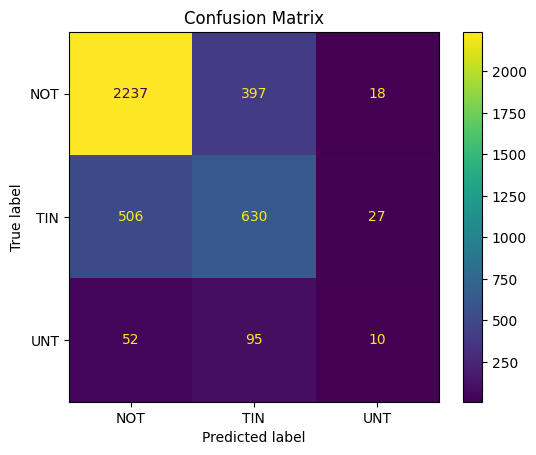

In [55]:
# Model 5 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m51 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6581
Precision (macro): 0.4304
Recall (macro):    0.3718
F1-score (macro):  0.3630


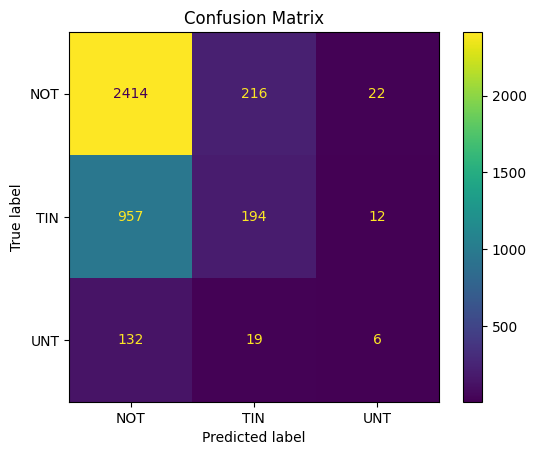

In [56]:
# Model 5 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m52 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7253
Precision (macro): 0.5279
Recall (macro):    0.4844
F1-score (macro):  0.4913


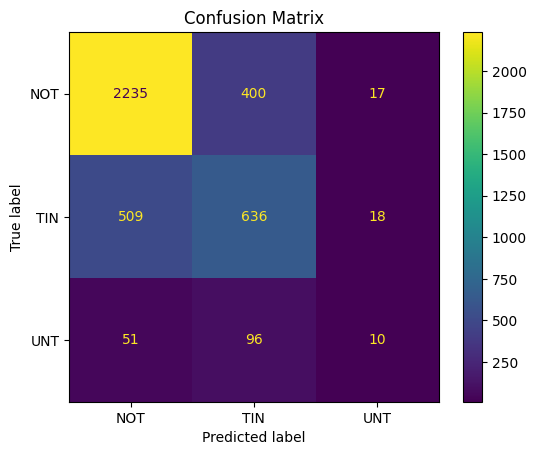

In [57]:
# Model 5 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m53 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6599
Precision (macro): 0.3667
Recall (macro):    0.3347
F1-score (macro):  0.2796


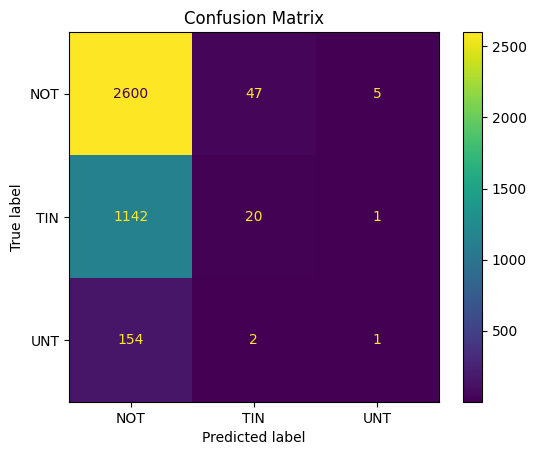

In [58]:
# Model 5 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m54 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7193
Precision (macro): 0.5069
Recall (macro):    0.4967
F1-score (macro):  0.5003


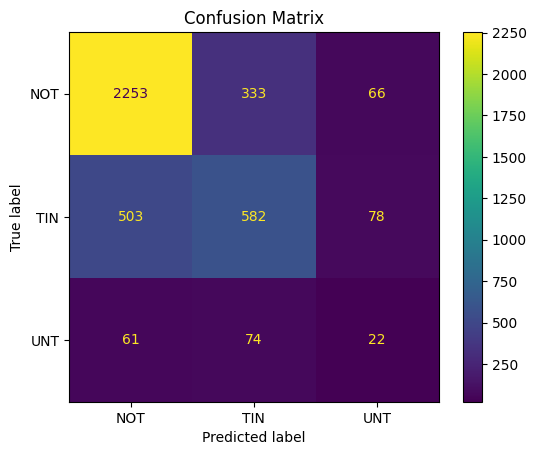

In [59]:
# Model 6 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m6 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7221
Precision (macro): 0.5037
Recall (macro):    0.4796
F1-score (macro):  0.4832


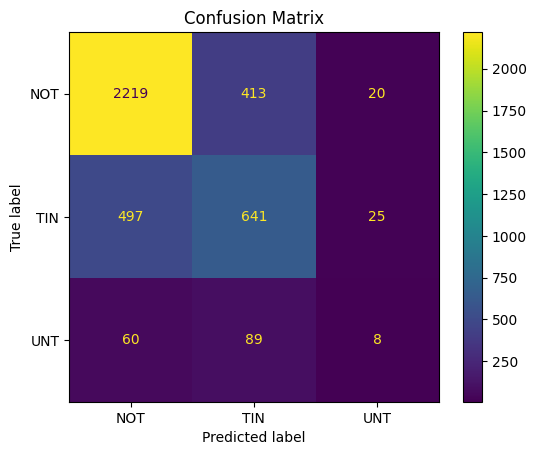

In [60]:
# Model 6 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m61 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6521
Precision (macro): 0.4137
Recall (macro):    0.3676
F1-score (macro):  0.3584


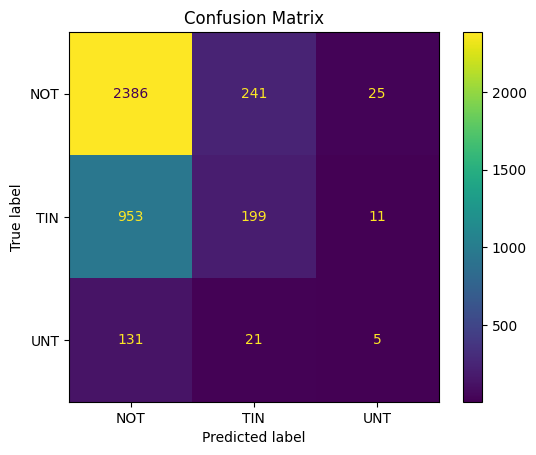

In [61]:
# Model 6 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m62 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7208
Precision (macro): 0.5139
Recall (macro):    0.4812
F1-score (macro):  0.4847


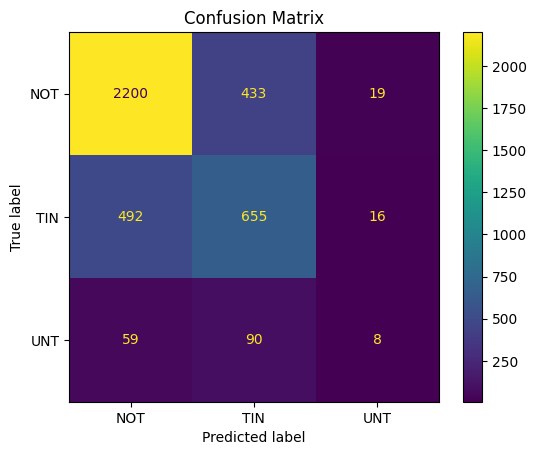

In [62]:
# Model 6 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m63 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6574
Precision (macro): 0.3682
Recall (macro):    0.3352
F1-score (macro):  0.2824


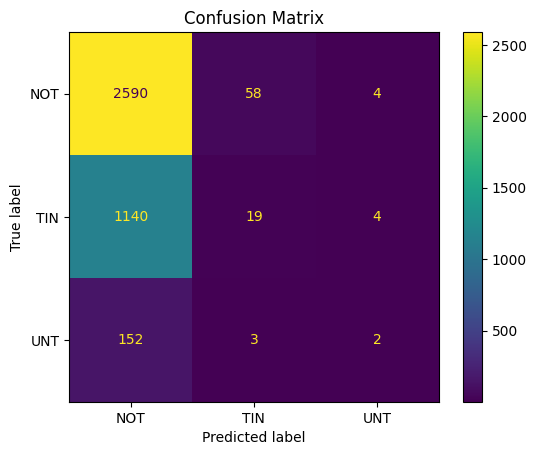

In [63]:
# Model 6 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m63 = get_SGDClassifier_predictions(X_train, X_val, y_train, y_val)

###**SGDClassifier pipeline**

In [64]:
# Build the pipeline
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 1),
        min_df=2,
        sublinear_tf=True,     # Apply log-scaling to term frequency
    )),
    ("clf", SGDClassifier(
        class_weight="balanced",
        max_iter=2000,
        tol=1e-3,     # Convergence tolerance
        random_state=42
    ))
])

In [65]:
# Hyperparameter grid
param_grid = {
    "clf__loss": ["hinge", "log_loss"],     # Loss function
    "clf__alpha": [1e-5, 1e-4, 1e-3],     # Regularization strength
    "clf__penalty": ["l2", "l1"],     # Regularization type
}

In [66]:
# Stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,     # Number of folds
    shuffle=True,
    random_state=42
)

In [67]:
# GridSearchCV
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,     # Stratified cross-validation
    n_jobs=-1,
    verbose=2
)

grid.fit(X_lemmatized_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(min_df=2,
                                                        sublinear_tf=True)),
                                       ('clf',
                                        SGDClassifier(class_weight='balanced',
                                                      max_iter=2000,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__alpha': [1e-05, 0.0001, 0.001],
                         'clf__loss': ['hinge', 'log_loss'],
                         'clf__penalty': ['l2', 'l1']},
             scoring='f1_macro', verbose=2)

In [68]:
print("Best params:", grid.best_params_)
print("Best CV macro F1:", grid.best_score_)

Best params: {'clf__alpha': 0.0001, 'clf__loss': 'log_loss', 'clf__penalty': 'l2'}
Best CV macro F1: 0.5205585003262694


In [69]:
# Evaluate on validation
best_model = grid.best_estimator_
y_val_pred = best_model.predict(X_lemmatized_val)     # Generate predictions

print("Confusion matrix:\n", metrics.confusion_matrix(y_val, y_val_pred))     # Confusion Matrix
print(metrics.classification_report(y_val, y_val_pred, digits=4))

Confusion matrix:
 [[2339  268   45]
 [ 577  514   72]
 [  66   58   33]]
              precision    recall  f1-score   support

         NOT     0.7844    0.8820    0.8303      2652
         TIN     0.6119    0.4420    0.5132      1163
         UNT     0.2200    0.2102    0.2150       157

    accuracy                         0.7266      3972
   macro avg     0.5388    0.5114    0.5195      3972
weighted avg     0.7116    0.7266    0.7132      3972

